# NOTE:
# The dataset is not included in this repository due to size limitations.
# Please download it from the following link before running the notebook:
# https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

                                                      1. Import all libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

                                                          2.  Load your datasets

In [2]:
true_df = pd.read_csv("true.csv")
fake_df = pd.read_csv("Fake.csv")

print("True shape:", true_df.shape)
print("Fake shape:", fake_df.shape)

True shape: (21417, 4)
Fake shape: (23481, 4)


                                                         3. Label & Merge datasets

In [3]:
true_df["label"] = 1     # True news
fake_df["label"] = 0     # Fake news

# Combine and shuffle
data = pd.concat([true_df, fake_df], axis=0)
data = data.sample(frac=1).reset_index(drop=True)

print("Combined shape:", data.shape)
data.head()

Combined shape: (44898, 5)


,title,text,subject,date,label
0,WATCH: British Students Laugh At Trump Stooge...,Corey Lewandowski was not prepared to be a jok...,News,"November 19, 2016",0
1,New Afghan peace talks expected in Oman but Ta...,"KABUL/PESHAWAR, Pakistan (Reuters) - Represent...",worldnews,"October 11, 2017",1
2,NAILS IT! POLLSTER PAT CADDELL Blasts The Obam...,Caddell s remarks came after hearing Michelle ...,politics,"Dec 20, 2016",0
3,OBAMA LIES ABOUT Number Of Troops On Ground In...,It was more important for Obama to keep a pled...,politics,"Mar 22, 2016",0
4,Hillary Beautifully Slams Trump’s ‘Dangerous’...,It s no doubt Hillary Clinton has made gun vio...,News,"May 22, 2016",0


                                                          4. Text Cleaning

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

data['text'] = data['text'].apply(clean_text)

                                                         5. Feature & Target Split


In [6]:
X = data['text']
y = data['label']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                                                          6. TF-IDF Vectorization

In [7]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

                                                         7. Train & Compare Models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))
    print("-" * 50)

✅ Logistic Regression Accuracy: 0.9850
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4719
           1       0.98      0.99      0.98      4261

    accuracy                           0.98      8980
   macro avg       0.98      0.99      0.98      8980
weighted avg       0.98      0.98      0.98      8980

--------------------------------------------------
✅ Random Forest Accuracy: 0.9987
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4719
           1       1.00      1.00      1.00      4261

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

--------------------------------------------------
✅ Naive Bayes Accuracy: 0.9248
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4719
           1       0.93      0.9

                                                         8. Compare Model Accuracies


/tmp/ipython-input-127965229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")


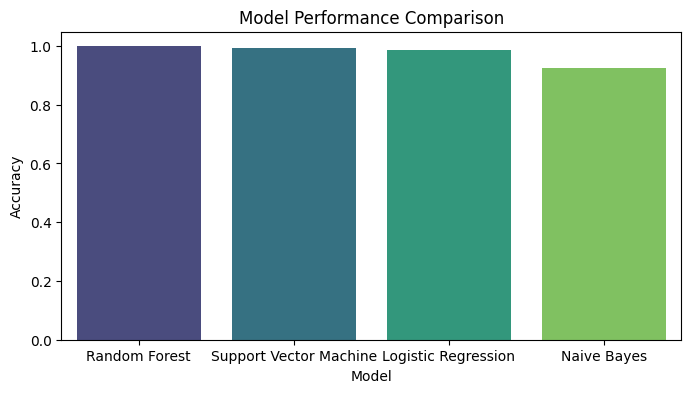


🏅 Best Model: Random Forest with Accuracy = 0.9987


In [9]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="Accuracy", palette="viridis")
plt.title("Model Performance Comparison")
plt.show()

best_model_name = results_df.iloc[0, 0]
best_accuracy = results_df.iloc[0, 1]
print(f"\n🏅 Best Model: {best_model_name} with Accuracy = {best_accuracy:.4f}")

                                                       9. Save Best Model (optional)


In [10]:
import joblib
best_model = models[best_model_name]
joblib.dump(best_model, "best_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel and vectorizer saved successfully!")


Model and vectorizer saved successfully!


                                                          10. Predict on New News

In [12]:
import joblib

# Load saved model and vectorizer
model = joblib.load("best_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

def predict_news(news_text):
    # Clean the input text (same function as before)
    cleaned = clean_text(news_text)
    # Transform using the TF-IDF vectorizer
    vectorized = vectorizer.transform([cleaned])
    # Make prediction
    pred = model.predict(vectorized)[0]
    if pred == 1:
        print("✅ This news is most likely TRUE (REAL).")
    else:
        print("⚠️ This news is most likely FAKE.")

# Example usage:
sample_news = "The government has announced a new policy to increase agricultural exports by 30% next year."
predict_news(sample_news)

# Or interactive input
user_input = input("📰 Enter any news headline or paragraph:\n")
predict_news(user_input)

⚠️ This news is most likely FAKE.
📰 Enter any news headline or paragraph:
Donald Trump is going to resign from presiident post
⚠️ This news is most likely FAKE.
